<a href="https://colab.research.google.com/github/roshansadath/COMP6721_Winter2023_GroupN/blob/main/Simple%20Chest%20XRay/ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
import os, time, random, torch, warnings
import numpy as np
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.simplefilter("ignore")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
data_path = "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI Driven Medical Imaging Models CNNs /Medical Image Diagnosis Convolutional Neural Networks/Simple_Chest_XRay"
#data_path = "/content/drive/My Drive/NIH_Chest_XRay/"
#data_path = "/content/drive/My Drive/Harvard_Chest_XRay/"

sample_ratio = 1
batch_size = 96
num_epochs = 20

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
def save_metrics(loss, accuracy, model):
  np.save("{}{}_train_loss.npy".format(data_path, model), loss)
  np.save("{}{}_train_accuracy.npy".format(data_path, model), accuracy)

**DATA PREPROCESSING**


In [12]:
%run "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI Driven Medical Imaging Models CNNs /Medical Image Diagnosis Convolutional Neural Networks/utils.ipynb"
dataset, train_loader, train_indices, test_loader, test_indices, val_loader, val_indices = data_preprocess(data_path, sample_ratio, batch_size)

 **DOWNLOAD RESNET18 MODEL AND TRAIN**


In [8]:
# Define the ResNet18 model and set Pretraining to False to train model from scratch
model = torch.hub.load('pytorch/vision:v0.9.0', 'resnet18', pretrained = False)
model.fc = nn.Linear(512, len(dataset.classes))
model.to(device)

# Define loss function a  s CrossEntropy and optimizer as Adam Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

losses, accuracies, v_accuracies, v_losses = train_model(model, criterion, optimizer, "ResNet18", num_epochs)

Downloading: "https://github.com/pytorch/vision/zipball/v0.9.0" to /root/.cache/torch/hub/v0.9.0.zip
Epoch 1/20: 100%|██████████| 1/1 [00:07<00:00,  7.87s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 2/20: 100%|██████████| 1/1 [00:02<00:00,  2.19s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 3/20: 100%|██████████| 1/1 [00:02<00:00,  2.26s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


...

VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 19/20: 100%|██████████| 1/1 [00:02<00:00,  2.63s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



Epoch 20/20: 100%|██████████| 1/1 [00:03<00:00,  3.39s/batch, Accuracy=1, Loss=0, Precision=1, Recall=1, F1 Score=1]


VALIDATION: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



**SAVE MODEL PARAMETERS**

In [9]:
torch.save(model.state_dict(), "{}resnet18.pth".format(data_path))

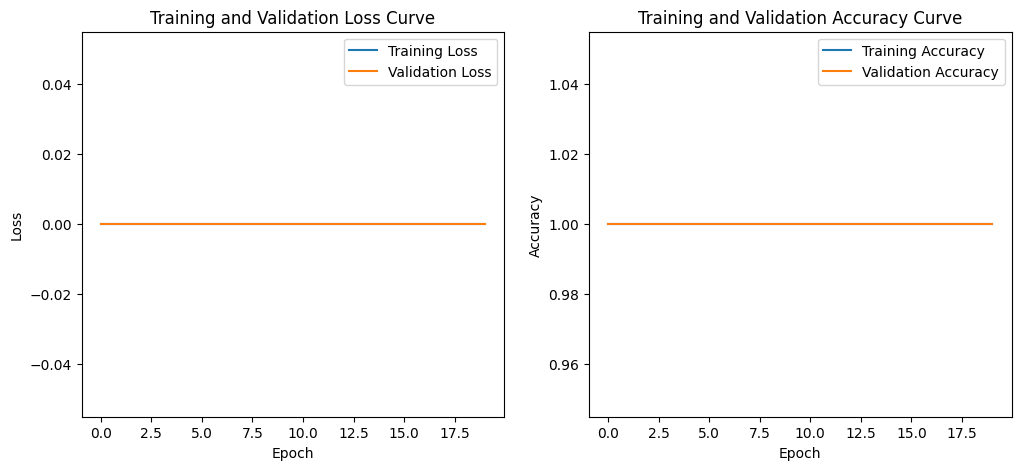

In [13]:
#Plot the Model Accuracy and Loss on Training and Validation Sets
plot_model_curves(losses, accuracies, v_accuracies, v_losses)

**EVALUATE MODEL ON TEST SET**

TEST: Accuracy: 1.0000 | Loss: 0.0000 | Recall: 1.0000 | Precision: 1.0000 | F-score: 1.0000



<Figure size 800x800 with 0 Axes>

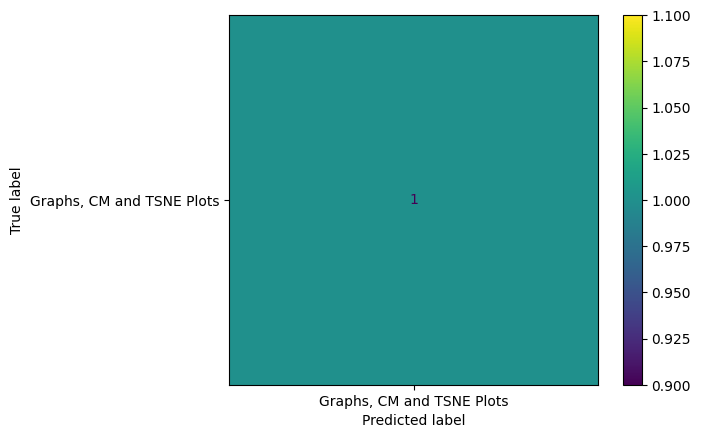

In [14]:
#Evaluate Model on Test Set
evaluate_model(model, test_loader, test_indices, 'TEST', criterion, data_path, "ResNet18")

In [15]:
#Obtain the TSNE Plot
plot_TSNE(train_loader, device, model)

ValueError: perplexity must be less than n_samples

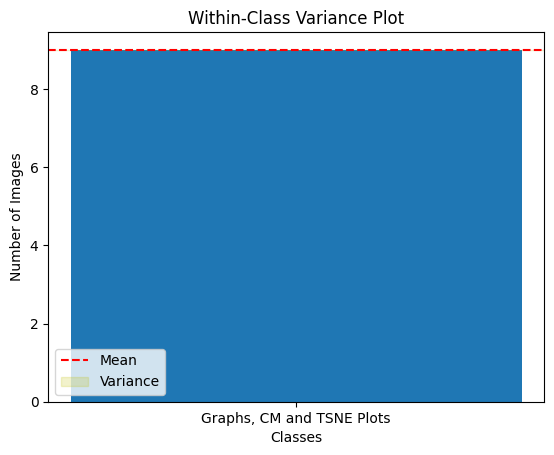

In [16]:
#Plot the Within-Class Variance of the dataset
plot_within_class_variance(dataset)